# Data Comparison: EM-DAT Disasters vs. ERA5 Risk Classification

This notebook compares **documented disasters** from the EM-DAT database with **computed risk levels** derived from ERA5 climate indices for **Jijiga City** (Somali Region, Ethiopia).

**ERA5 grid point:** 42.75°E / 9.25°N (nearest grid point to Jijiga)  
**Period:** 2000–2025  
**Risk types:** Drought (SPEI + API + SMI + Runoff) and Flood (API + SMI + Runoff)

> **Note — initial exploration notebook:** The SPEI and API values used here are the raw approximations stored in `era5_2000_2025.parquet` (30-day rolling SPEI, API with k=0.85). Phase 3 recomputes both indices properly (SPEI-6/12 via log-logistic distribution, API with k=0.92). The risk classifier also uses the initial **5-class scheme** (Low, Moderate, Elevated, High, Extreme); Phase 3 revised this to a **4-class scheme** aligned with McKee (1993) SPEI thresholds. This notebook is preserved to show where the design started.

In [15]:
import sys
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

sys.path.insert(0, "../src")
from modeling import DroughtRiskClassifier, FloodRiskClassifier, RiskLevel

# Paths
ERA5_PATH  = "../src/data/processed/era5_2000_2025.parquet"
EMDAT_PATH = "../src/data/processed/emdat.xlsx"

RISK_COLORS = {
    RiskLevel.LOW:      "#2ecc71",
    RiskLevel.MODERATE: "#f1c40f",
    RiskLevel.ELEVATED: "#e67e22",
    RiskLevel.HIGH:     "#e74c3c",
    RiskLevel.EXTREME:  "#8e44ad",
}
RISK_NUMERIC = {r: r.numeric for r in RiskLevel}
print("Imports OK")
import os; os.makedirs("figures", exist_ok=True)

Imports OK


## 1. Load ERA5 data and compute risk levels

In [16]:
era5_raw = pd.read_parquet(ERA5_PATH)
era5_raw["time"] = pd.to_datetime(era5_raw["time"])
era5 = era5_raw.set_index("time").sort_index()
era5 = era5.drop(columns=["longitude", "latitude", "number"], errors="ignore")
# Raw SPEI column is a 30-day rolling approximation; fill leading NaN with 0 (neutral condition)
era5["spei"] = era5["spei"].fillna(0)

print(f"ERA5 period  : {era5.index.min().date()} → {era5.index.max().date()}")
print(f"Location     : lon={era5_raw['longitude'].iloc[0]:.2f}°E, lat={era5_raw['latitude'].iloc[0]:.2f}°N")
print(f"Columns      : {list(era5.columns)}")
era5[["spei", "api", "smi", "total_ro"]].describe().round(4)

ERA5 period  : 2000-01-01 → 2025-12-31
Location     : lon=42.75°E, lat=9.25°N
Columns      : ['u10', 'v10', 'd2m', 't2m', 'sp', 'swvl1', 'swvl2', 'tp', 'ssrd', 'e', 'pev', 'ssro', 'sro', 'lsp', 'vimd', 'total_ro', 'api', 'smi', 'spei']


,spei,api,smi,total_ro
count,9497.0000,9497.0000,9497.0000,9497.0000
mean,-0.0513,0.0011,0.2833,0.0000
std,0.9916,0.0016,0.1938,0.0001
min,-4.7534,0.0000,0.0000,0.0000
25%,-0.7203,0.0001,0.1134,0.0000
50%,0.1146,0.0005,0.2444,0.0000
75%,0.6811,0.0014,0.3979,0.0000
max,2.0590,0.0145,1.0000,0.0020


In [17]:
drought_clf = DroughtRiskClassifier()
drought_clf.fit(era5)
era5["drought_risk"] = drought_clf.classify(era5)

flood_clf = FloodRiskClassifier()
flood_clf.fit(era5)
era5["flood_risk"] = flood_clf.classify(era5)

era5["drought_num"] = era5["drought_risk"].map(RISK_NUMERIC)
era5["flood_num"]   = era5["flood_risk"].map(RISK_NUMERIC)

print("\nDrought risk distribution:")
print(era5["drought_risk"].value_counts().rename(lambda r: r.value))
print("\nFlood risk distribution:")
print(era5["flood_risk"].value_counts().rename(lambda r: r.value))


Drought risk distribution:
drought_risk
Laag risico         6546
Verhoogd risico      911
Hoog risico          891
Extreem risico       778
Gemiddeld risico     371
Name: count, dtype: int64

Flood risk distribution:
flood_risk
Laag risico         6173
Gemiddeld risico    1424
Verhoogd risico      950
Hoog risico          665
Extreem risico       285
Name: count, dtype: int64


## 2. Load and explore EM-DAT data

In [18]:
emdat_raw = pd.read_excel(EMDAT_PATH)
print(f"EM-DAT rows    : {len(emdat_raw):,}")
print(f"EM-DAT columns : {list(emdat_raw.columns)}")

EM-DAT rows    : 1,201
EM-DAT columns : ['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


In [19]:
# Normalise column names for robust matching (EM-DAT schema varies across versions)
emdat_raw.columns = emdat_raw.columns.str.strip()

country_col = next(
    (c for c in emdat_raw.columns if "country" in c.lower()), None
)
type_col = next(
    (c for c in emdat_raw.columns if c.lower() in ("disaster type", "disastertype", "type")), None
)
loc_col = next(
    (c for c in emdat_raw.columns if "location" in c.lower()), None
)
start_year_col = next(
    (c for c in emdat_raw.columns if "start year" in c.lower() or c.lower() == "year"), None
)
start_month_col = next(
    (c for c in emdat_raw.columns if "start month" in c.lower()), None
)
start_day_col = next(
    (c for c in emdat_raw.columns if "start day" in c.lower()), None
)
end_year_col = next(
    (c for c in emdat_raw.columns if "end year" in c.lower()), None
)
end_month_col = next(
    (c for c in emdat_raw.columns if "end month" in c.lower()), None
)
end_day_col = next(
    (c for c in emdat_raw.columns if "end day" in c.lower()), None
)

print("Detected column names:")
for label, col in [
    ("country",     country_col),
    ("type",        type_col),
    ("location",    loc_col),
    ("start_year",  start_year_col),
    ("start_month", start_month_col),
    ("start_day",   start_day_col),
    ("end_year",    end_year_col),
    ("end_month",   end_month_col),
    ("end_day",     end_day_col),
]:
    print(f"  {label:12s}: {col}")

Detected column names:
  country     : Country
  type        : Disaster Type
  location    : Location
  start_year  : Start Year
  start_month : Start Month
  start_day   : Start Day
  end_year    : End Year
  end_month   : End Month
  end_day     : End Day


In [20]:
# Filter to Ethiopia, flood and drought events only
eth = emdat_raw.copy()

if country_col:
    eth = eth[eth[country_col].str.lower().str.contains("ethiopia", na=False)]

if type_col:
    eth = eth[
        eth[type_col].str.lower().str.contains("flood|drought", na=False)
    ]

print(f"Ethiopian flood/drought disasters: {len(eth)}")

if type_col:
    print("\nDisaster types:")
    print(eth[type_col].value_counts())

Ethiopian flood/drought disasters: 48

Disaster types:
Disaster Type
Flood      39
Drought     9
Name: count, dtype: int64


In [21]:
def build_date(year_s, month_s, day_s, fallback_month=1, fallback_day=1):
    """Build a date Series from separate year/month/day columns (EM-DAT format)."""
    year  = pd.to_numeric(year_s,  errors="coerce").fillna(0).astype(int)
    month = pd.to_numeric(month_s, errors="coerce").fillna(fallback_month).astype(int).clip(1, 12)
    day   = pd.to_numeric(day_s,   errors="coerce").fillna(fallback_day).astype(int).clip(1, 28)
    valid = year > 0
    result = pd.Series(pd.NaT, index=year_s.index, dtype="datetime64[ns]")
    if valid.any():
        result.loc[valid] = pd.to_datetime(
            {"year": year[valid], "month": month[valid], "day": day[valid]}
        ).values
    return result


if start_year_col:
    eth = eth.copy()
    eth["start_date"] = build_date(
        eth[start_year_col],
        eth.get(start_month_col, pd.Series(1, index=eth.index)),
        eth.get(start_day_col,   pd.Series(1, index=eth.index)),
    )
    eth["end_date"] = build_date(
        eth[end_year_col] if end_year_col else eth[start_year_col],
        eth.get(end_month_col, pd.Series(12, index=eth.index)),
        eth.get(end_day_col,   pd.Series(28, index=eth.index)),
        fallback_month=12,
        fallback_day=28,
    )

# Restrict to ERA5 coverage period
eth = eth[
    (eth["start_date"] >= era5.index.min()) &
    (eth["start_date"] <= era5.index.max())
].copy()

print(f"Disasters within ERA5 period (2000–2025): {len(eth)}")
cols_show = [c for c in [country_col, type_col, loc_col, "start_date", "end_date"] if c]
eth[cols_show].sort_values("start_date").head(10)

Disasters within ERA5 period (2000–2025): 47


,Country,Disaster Type,Location,start_date,end_date
503,Ethiopia,Flood,"Nazareth city (East Shewa district, Oromia pro...",2000-06-28,2000-06-28
504,Ethiopia,Flood,"Dubti area (Zone 1 district, Afar province)",2000-08-10,2000-08-21
770,Ethiopia,Flood,Gambela province,2001-07-01,2001-07-28
72,Ethiopia,Flood,"Himora town (Western district, Tigray province)",2001-08-01,2001-08-28
1194,Ethiopia,Flood,"Dubti, Asaita areas (Zone 1 district, Afar pro...",2001-08-10,2001-08-10
99,Ethiopia,Flood,"Afar, Oromia, Somali region",2002-04-16,2002-04-21
540,Ethiopia,Drought,"Tigray, Oromia, Amhara, Somali, Afar provinces",2003-01-01,2004-12-28
532,Ethiopia,Flood,Somali province,2003-04-28,2003-05-20
362,Ethiopia,Flood,"Dire Dawa, Somali provinces",2005-04-23,2005-04-26
1158,Ethiopia,Flood,Dire Dawa province,2005-05-20,2005-05-22


In [22]:
# Filter to Jijiga / Somali Region; fall back to all-Ethiopia if fewer than 3 matches
jijiga_keywords = ["jijiga", "somali", "ogaden", "jigjiga"]

if loc_col:
    loc_lower = eth[loc_col].fillna("").str.lower()
    eth_jijiga = eth[
        loc_lower.str.contains("|".join(jijiga_keywords), na=False)
    ].copy()
else:
    eth_jijiga = eth.copy()

print(f"Disasters with Jijiga/Somali location: {len(eth_jijiga)}")

disasters = eth_jijiga if len(eth_jijiga) >= 3 else eth
label_scope = "Jijiga / Somali Region" if len(eth_jijiga) >= 3 else "Ethiopia (broad)"
print(f"Analysis scope: {label_scope} ({len(disasters)} disasters)")
disasters[[c for c in [type_col, loc_col, "start_date", "end_date"] if c]].sort_values("start_date")

Disasters with Jijiga/Somali location: 26
Analysis scope: Jijiga / Somali Region (26 disasters)


,Disaster Type,Location,start_date,end_date
99,Flood,"Afar, Oromia, Somali region",2002-04-16,2002-04-21
540,Drought,"Tigray, Oromia, Amhara, Somali, Afar provinces",2003-01-01,2004-12-28
532,Flood,Somali province,2003-04-28,2003-05-20
362,Flood,"Dire Dawa, Somali provinces",2005-04-23,2005-04-26
1153,Drought,"Afder, Liben districts (Somali province), Gode...",2005-11-01,2006-12-28
1154,Flood,"Afar, Somali provinces",2006-04-09,2006-04-25
569,Flood,"Gode, Kelafo, Mustahil, East Imi, Ferfer, Dena...",2006-10-27,2006-12-18
1132,Flood,"Gambela, Amhara, SNNPR, Addis Ababa, Afar, Tig...",2007-07-28,2007-10-05
1112,Drought,"Oromia, Somali, Amhara, Afar, Tigray, SNNPR pr...",2008-05-01,2009-10-28
1122,Flood,"Jijiga town (Fafan district, Somali province)",2008-05-28,2008-05-28


## 3. Timeline comparison: Drought

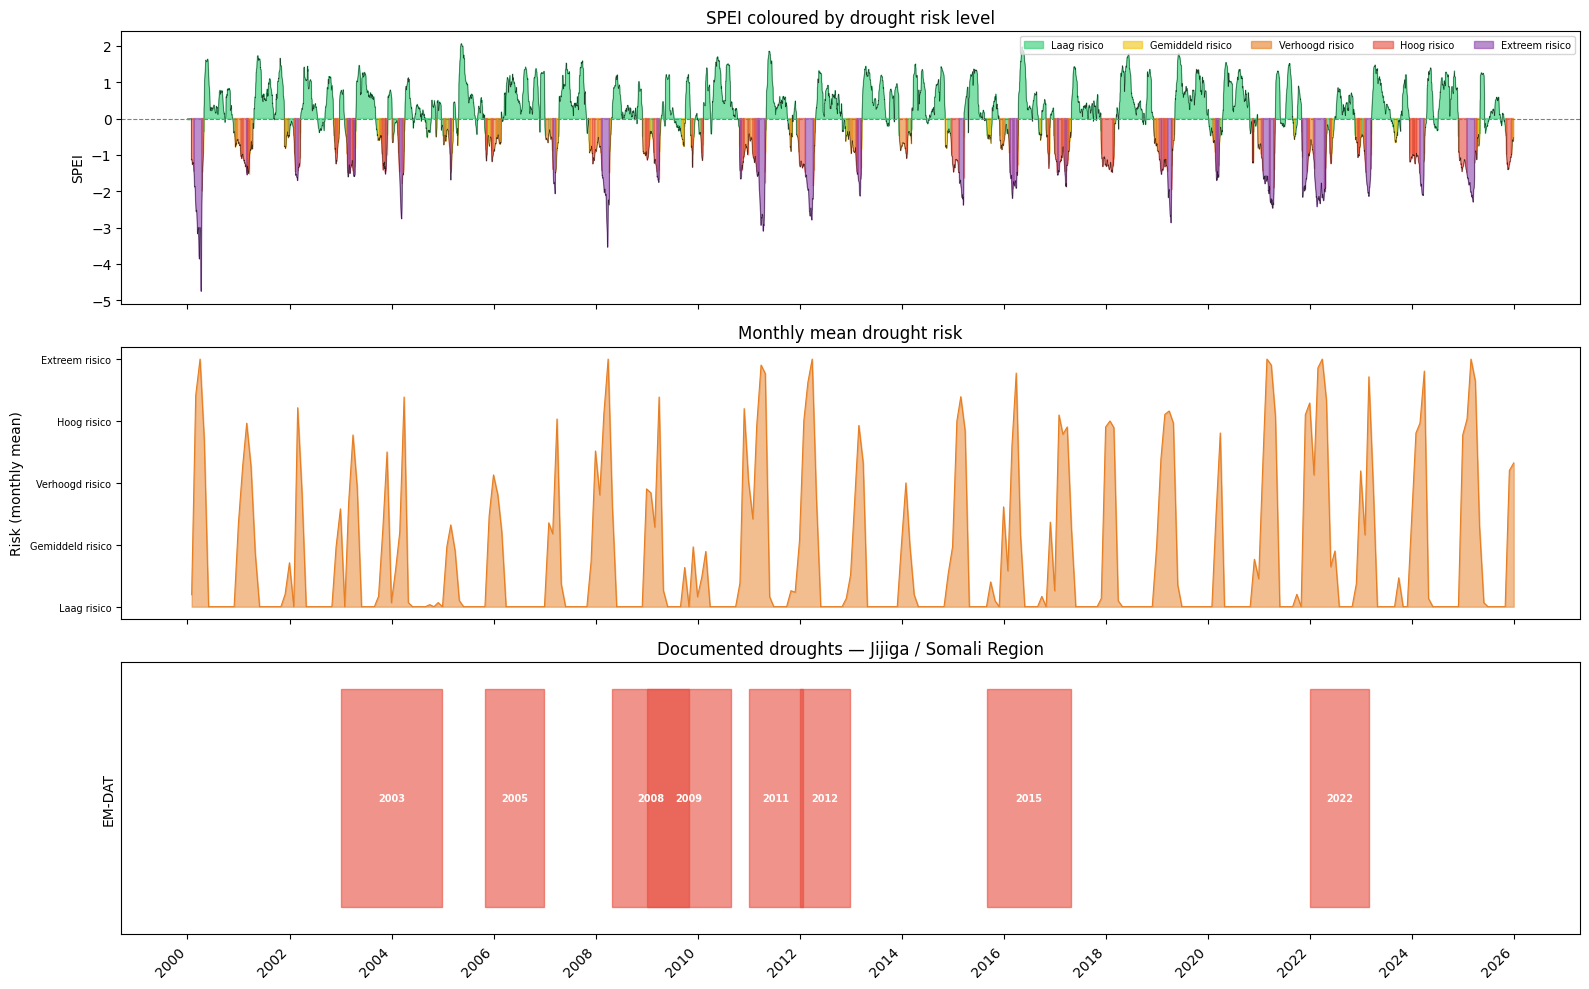

EM-DAT drought events: 8


In [23]:
drought_events = disasters[
    disasters[type_col].str.lower().str.contains("drought", na=False)
] if type_col else disasters

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Panel 1: SPEI time series coloured by drought risk level
ax = axes[0]
for level in RiskLevel:
    mask = era5["drought_risk"] == level
    ax.fill_between(era5.index, era5["spei"], where=mask,
                    color=RISK_COLORS[level], alpha=0.6, label=level.value)
ax.plot(era5.index, era5["spei"], color="k", lw=0.4, alpha=0.7)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("SPEI")
ax.set_title("SPEI coloured by drought risk level")
ax.legend(loc="upper right", fontsize=7, ncol=5)

# Panel 2: Monthly mean drought risk level
ax = axes[1]
monthly_drought = era5["drought_num"].resample("ME").mean()
ax.fill_between(monthly_drought.index, monthly_drought, alpha=0.5, color="#e67e22")
ax.plot(monthly_drought.index, monthly_drought, color="#e67e22", lw=0.8)
ax.set_yticks(range(5))
ax.set_yticklabels([r.value for r in RiskLevel], fontsize=7)
ax.set_ylabel("Risk (monthly mean)")
ax.set_title("Monthly mean drought risk")

# Panel 3: EM-DAT drought events as coloured bands
ax = axes[2]
ax.set_ylabel("EM-DAT")
ax.set_title(f"Documented droughts — {label_scope}")
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([])
if len(drought_events) > 0:
    for _, row in drought_events.iterrows():
        s = row["start_date"]
        e = row["end_date"] if pd.notna(row["end_date"]) else s + pd.Timedelta(days=30)
        ax.axvspan(s, e, ymin=0.1, ymax=0.9,
                   color="#e74c3c", alpha=0.6, label="Drought (EM-DAT)")
        ax.text(s + (e - s) / 2, 0.5, str(s.year),
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
else:
    ax.text(0.5, 0.5, "No droughts found in filtered range",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="gray")

axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.savefig("figures/drought_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"EM-DAT drought events: {len(drought_events)}")

## 4. Timeline comparison: Flood

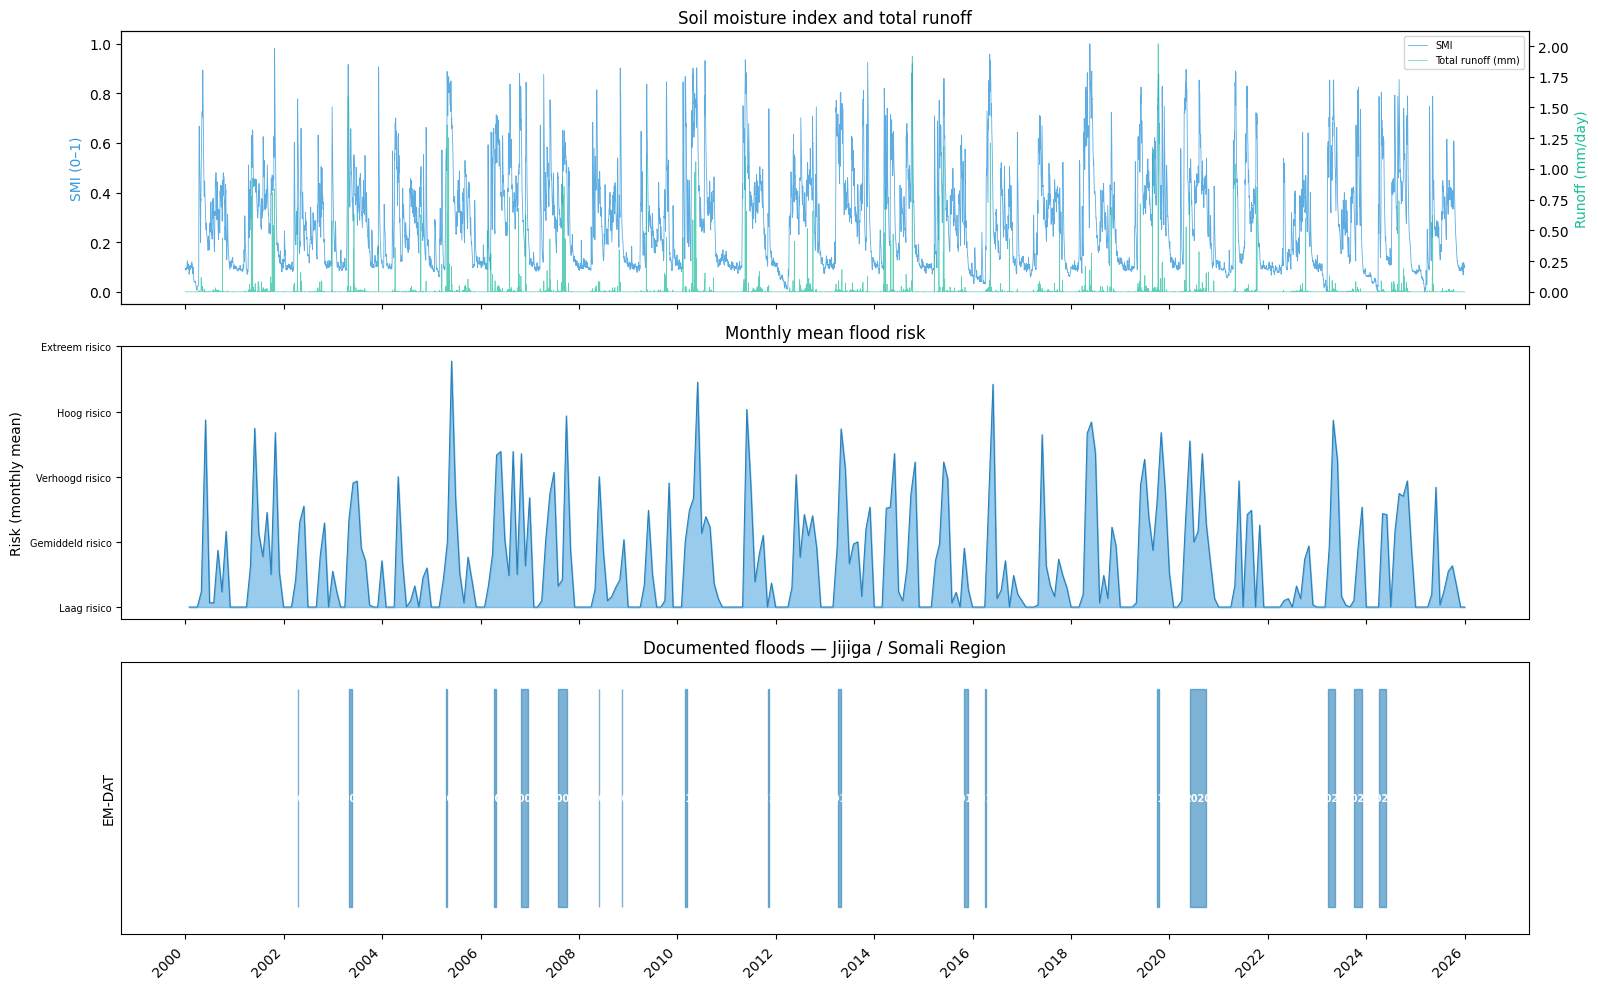

EM-DAT flood events: 18


In [24]:
flood_events = disasters[
    disasters[type_col].str.lower().str.contains("flood", na=False)
] if type_col else disasters

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Panel 1: SMI and total runoff
ax = axes[0]
ax2 = ax.twinx()
ax.plot(era5.index, era5["smi"], color="#3498db", lw=0.6, label="SMI", alpha=0.8)
ax2.plot(era5.index, era5["total_ro"] * 1000, color="#1abc9c", lw=0.5,
         label="Total runoff (mm)", alpha=0.7)
ax.set_ylabel("SMI (0–1)", color="#3498db")
ax2.set_ylabel("Runoff (mm/day)", color="#1abc9c")
ax.set_title("Soil moisture index and total runoff")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=7)

# Panel 2: Monthly mean flood risk level
ax = axes[1]
monthly_flood = era5["flood_num"].resample("ME").mean()
ax.fill_between(monthly_flood.index, monthly_flood, alpha=0.5, color="#3498db")
ax.plot(monthly_flood.index, monthly_flood, color="#2980b9", lw=0.8)
ax.set_yticks(range(5))
ax.set_yticklabels([r.value for r in RiskLevel], fontsize=7)
ax.set_ylabel("Risk (monthly mean)")
ax.set_title("Monthly mean flood risk")

# Panel 3: EM-DAT flood events
ax = axes[2]
ax.set_ylabel("EM-DAT")
ax.set_title(f"Documented floods — {label_scope}")
ax.set_ylim(-0.5, 1.5)
ax.set_yticks([])
if len(flood_events) > 0:
    for _, row in flood_events.iterrows():
        s = row["start_date"]
        e = row["end_date"] if pd.notna(row["end_date"]) else s + pd.Timedelta(days=14)
        ax.axvspan(s, e, ymin=0.1, ymax=0.9,
                   color="#2980b9", alpha=0.6)
        ax.text(s + (e - s) / 2, 0.5, str(s.year),
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
else:
    ax.text(0.5, 0.5, "No floods found in filtered range",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="gray")

axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.savefig("figures/flood_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"EM-DAT flood events: {len(flood_events)}")

## 5. Risk level around EM-DAT events

In [25]:
def risk_during_event(event_row, risk_col, window_days=30):
    """Mean risk level in the +/-window_days window around an EM-DAT event."""
    s = event_row["start_date"] - pd.Timedelta(days=window_days)
    e = (event_row["end_date"]
         if pd.notna(event_row["end_date"])
         else event_row["start_date"]) + pd.Timedelta(days=window_days)
    segment = era5.loc[s:e, risk_col]
    if len(segment) == 0:
        return np.nan
    return segment.mean()


records = []
for _, row in disasters.iterrows():
    t = row[type_col].lower() if type_col else "unknown"
    if "drought" in t:
        risk_mean = risk_during_event(row, "drought_num")
        risk_label = "Drought"
    elif "flood" in t:
        risk_mean = risk_during_event(row, "flood_num")
        risk_label = "Flood"
    else:
        continue
    records.append({
        "type":          risk_label,
        "start_date":    row["start_date"],
        "end_date":      row["end_date"],
        "location":      row.get(loc_col, "") if loc_col else "",
        "risk_mean":     risk_mean,
        "risk_category": list(RiskLevel)[min(round(risk_mean), 4)].value if not np.isnan(risk_mean) else "N/A",
    })

summary = pd.DataFrame(records).sort_values("start_date")
summary

,type,start_date,end_date,location,risk_mean,risk_category
0,Flood,2002-04-16,2002-04-21,"Afar, Oromia, Somali region",1.363636,Gemiddeld risico
12,Drought,2003-01-01,2004-12-28,"Tigray, Oromia, Amhara, Somali, Afar provinces",0.700508,Gemiddeld risico
11,Flood,2003-04-28,2003-05-20,Somali province,1.698795,Verhoogd risico
3,Flood,2005-04-23,2005-04-26,"Dire Dawa, Somali provinces",2.078125,Verhoogd risico
24,Drought,2005-11-01,2006-12-28,"Afder, Liben districts (Somali province), Gode...",0.492754,Laag risico
25,Flood,2006-04-09,2006-04-25,"Afar, Somali provinces",2.025974,Verhoogd risico
13,Flood,2006-10-27,2006-12-18,"Gode, Kelafo, Mustahil, East Imi, Ferfer, Dena...",1.274336,Gemiddeld risico
23,Flood,2007-07-28,2007-10-05,"Gambela, Amhara, SNNPR, Addis Ababa, Afar, Tig...",1.084615,Gemiddeld risico
21,Drought,2008-05-01,2009-10-28,"Oromia, Somali, Amhara, Afar, Tigray, SNNPR pr...",0.592409,Gemiddeld risico
22,Flood,2008-05-28,2008-05-28,"Jijiga town (Fafan district, Somali province)",1.442623,Gemiddeld risico


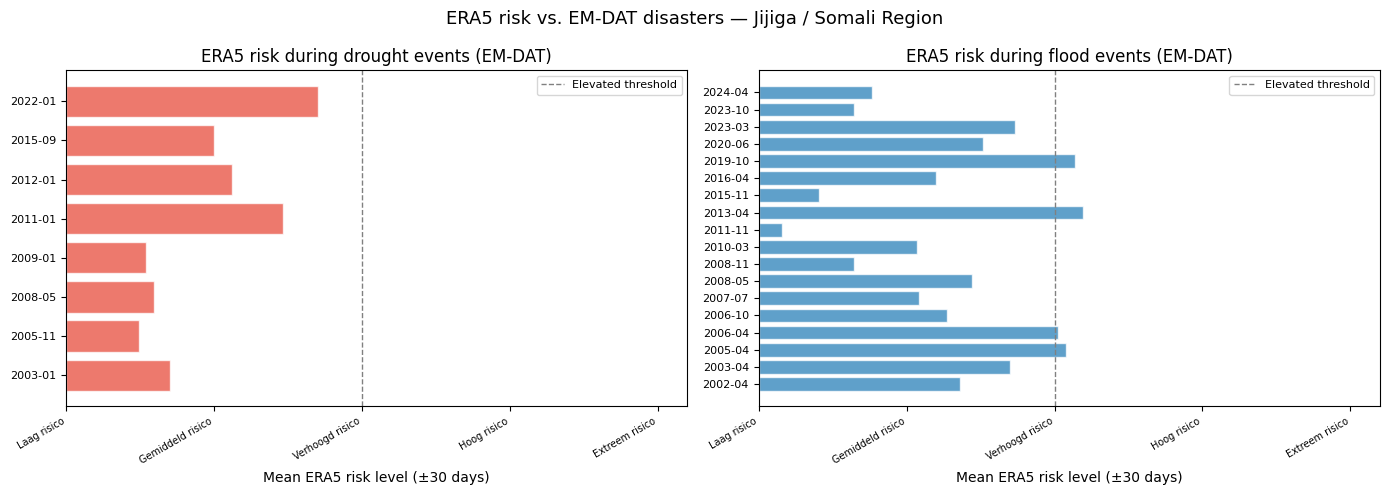

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rtype, color in zip(axes, ["Drought", "Flood"], ["#e74c3c", "#2980b9"]):
    sub = summary[summary["type"] == rtype]
    if sub.empty:
        ax.text(0.5, 0.5, f"No {rtype.lower()} data",
                transform=ax.transAxes, ha="center", fontsize=12)
        ax.set_title(rtype)
        continue

    ax.barh(
        range(len(sub)),
        sub["risk_mean"],
        color=color, alpha=0.75, edgecolor="white"
    )
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(
        [f"{r['start_date'].strftime('%Y-%m')}" for _, r in sub.iterrows()],
        fontsize=8,
    )
    ax.axvline(2, color="gray", ls="--", lw=1, label="Elevated threshold")
    ax.set_xlim(0, 4.2)
    ax.set_xticks(range(5))
    ax.set_xticklabels([r.value for r in RiskLevel], rotation=30, ha="right", fontsize=7)
    ax.set_xlabel("Mean ERA5 risk level (±30 days)")
    ax.set_title(f"ERA5 risk during {rtype.lower()} events (EM-DAT)")
    ax.legend(fontsize=8)

fig.suptitle(f"ERA5 risk vs. EM-DAT disasters — {label_scope}", fontsize=13)
fig.tight_layout()
plt.savefig("figures/emdat_risk_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Seasonal pattern: EM-DAT vs. high ERA5 risk

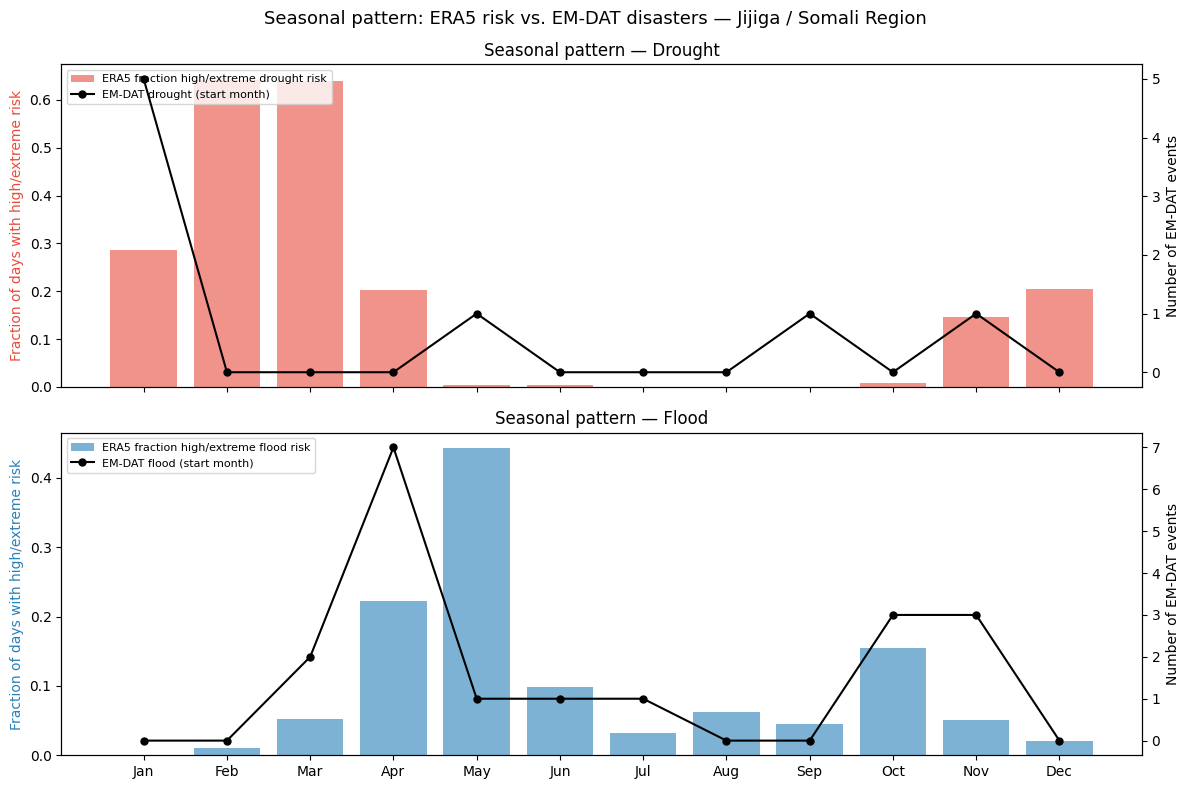

In [27]:
# Fraction of days per month with High or Extreme risk (ERA5)
# Use lambda groupby to avoid adding a permanent 'month' column to the dataframe
def by_month(df):
    return df.groupby(lambda t: t.month)


drought_high = (
    by_month(era5[era5["drought_num"] >= 3])
    .size()
    .reindex(range(1, 13), fill_value=0)
    / by_month(era5).size()
)
flood_high = (
    by_month(era5[era5["flood_num"] >= 3])
    .size()
    .reindex(range(1, 13), fill_value=0)
    / by_month(era5).size()
)

# Count EM-DAT disaster start months
disaster_months = {
    "Drought": disasters[disasters[type_col].str.lower().str.contains("drought", na=False)]["start_date"].dt.month.value_counts().reindex(range(1, 13), fill_value=0),
    "Flood":   disasters[disasters[type_col].str.lower().str.contains("flood",   na=False)]["start_date"].dt.month.value_counts().reindex(range(1, 13), fill_value=0),
} if type_col else {}

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
x = np.arange(12)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, risk_series, color, label, key in [
    (axes[0], drought_high, "#e74c3c", "Drought", "Drought"),
    (axes[1], flood_high,   "#2980b9", "Flood",   "Flood"),
]:
    ax.bar(x, risk_series.values, color=color, alpha=0.6,
           label=f"ERA5 fraction high/extreme {label.lower()} risk")
    ax.set_ylabel("Fraction of days with high/extreme risk", color=color)
    ax.set_title(f"Seasonal pattern — {label}")
    ax2 = ax.twinx()
    if key in disaster_months:
        ax2.plot(x, disaster_months[key].values, "o-", color="black",
                 lw=1.5, ms=5, label=f"EM-DAT {label.lower()} (start month)")
        ax2.set_ylabel("Number of EM-DAT events", color="black")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(month_labels)
fig.suptitle(f"Seasonal pattern: ERA5 risk vs. EM-DAT disasters — {label_scope}", fontsize=13)
fig.tight_layout()
plt.savefig("figures/seasonal_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary

In [28]:
n_drought = len(drought_events)
n_flood   = len(flood_events)

if not summary.empty:
    drought_sum = summary[summary["type"] == "Drought"]
    flood_sum   = summary[summary["type"] == "Flood"]

    pct_drought_detected = (
        (drought_sum["risk_mean"] >= 2).sum() / max(len(drought_sum), 1) * 100
    )
    pct_flood_detected = (
        (flood_sum["risk_mean"] >= 2).sum() / max(len(flood_sum), 1) * 100
    )
else:
    pct_drought_detected = pct_flood_detected = float("nan")

print("=" * 60)
print("DATA COMPARISON SUMMARY")
print(f"Scope        : {label_scope}")
print(f"ERA5 period  : {era5.index.min().date()} → {era5.index.max().date()}")
print("-" * 60)
print(f"EM-DAT droughts : {n_drought}")
print(f"EM-DAT floods   : {n_flood}")
print("-" * 60)
print(f"ERA5 detection droughts (mean >= 'Elevated') : {pct_drought_detected:.0f}%")
print(f"ERA5 detection floods   (mean >= 'Elevated') : {pct_flood_detected:.0f}%")
print("=" * 60)
print()
print("Note: ERA5 grid point (42.75\u00b0E / 9.25\u00b0N) is the nearest point to Jijiga City.")
print("  Local topography and microclimate may differ from EM-DAT field observations.")
print("  Low detection rates here motivated the improved classifier design in Phase 3.")

DATA COMPARISON SUMMARY
Scope        : Jijiga / Somali Region
ERA5 period  : 2000-01-01 → 2025-12-31
------------------------------------------------------------
EM-DAT droughts : 8
EM-DAT floods   : 18
------------------------------------------------------------
ERA5 detection droughts (mean >= 'Elevated') : 0%
ERA5 detection floods   (mean >= 'Elevated') : 22%

Note: ERA5 grid point (42.75°E / 9.25°N) is the nearest point to Jijiga City.
  Local topography and microclimate may differ from EM-DAT field observations.
  Low detection rates here motivated the improved classifier design in Phase 3.
